In [86]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski

### Data Preprocessing

In [87]:
df = pd.read_csv("data/bioactivity_preprocessed_data.csv")
df

,molecule_chembl_id,canonical_smiles,standard_value,bioactivity_class
0,CHEMBL311039,CC12CCC(C1)C(C)(C)C2NS(=O)(=O)c1ccc(F)cc1,5000.0,intermediate
1,CHEMBL450926,CC12CC[C@@H](C1)C(C)(C)[C@@H]2NS(=O)(=O)c1cccs1,2700.0,intermediate
2,CHEMBL310242,CC12CC[C@@H](C1)C(C)(C)[C@@H]2NS(=O)(=O)c1ccc(...,1800.0,intermediate
3,CHEMBL74874,CC12CC[C@@H](C1)C(C)(C)[C@@H]2NS(=O)(=O)c1ccc(...,11000.0,inactive
4,CHEMBL75183,CC12CC[C@@H](C1)C(C)(C)[C@@H]2NS(=O)(=O)c1ccc(...,10000.0,inactive
...,...,...,...,...
1621,CHEMBL3653692,CC1=NC2(N=C1N)c1cc(Br)ccc1CC21CCC(F)(F)CC1,399.0,active
1622,CHEMBL3653693,CC1=NC2(N=C1N)c1cc(-c3cncc(Cl)c3)ccc1CC21CCC(F...,53.0,intermediate
1623,CHEMBL3653693,CC1=NC2(N=C1N)c1cc(-c3cncc(Cl)c3)ccc1CC21CCC(F...,109.0,intermediate
1624,CHEMBL3653694,CC1=NC2(N=C1N)c1cc(NC(=O)c3ccc(Cl)cn3)ccc1CC21...,408.0,active


#### Calculate Lipinski descriptors
MW (Molecular Weight) = size \
LogP = solubility \
NumHDonors = # hydrogen bond donors \
NumHAcceptors = # hydrogen bond acceptors

In [88]:

# Inspired by: https://codeocean.com/explore/capsules?query=tag:data-curation

def lipinski(smiles, verbose=False):

    moldata= []
    for elem in smiles:
        mol=Chem.MolFromSmiles(elem) 
        moldata.append(mol)
       
    baseData= np.arange(1,1)
    i=0  
    for mol in moldata:        
       
        desc_MolWt = Descriptors.MolWt(mol)
        desc_MolLogP = Descriptors.MolLogP(mol)
        desc_NumHDonors = Lipinski.NumHDonors(mol)
        desc_NumHAcceptors = Lipinski.NumHAcceptors(mol)
           
        row = np.array([desc_MolWt,
                        desc_MolLogP,
                        desc_NumHDonors,
                        desc_NumHAcceptors])   
    
        if(i==0):
            baseData=row
        else:
            baseData=np.vstack([baseData, row])
        i=i+1      
    
    columnNames=["MW","LogP","NumHDonors","NumHAcceptors"]   
    descriptors = pd.DataFrame(data=baseData,columns=columnNames)
    
    return descriptors

In [89]:
df_lipinski = lipinski(df.canonical_smiles)
df_lipinski

,MW,LogP,NumHDonors,NumHAcceptors
0,311.422,3.3188,1.0,2.0
1,299.461,3.2412,1.0,3.0
2,311.422,3.3188,1.0,2.0
3,327.877,3.8331,1.0,2.0
4,372.328,3.9422,1.0,2.0
...,...,...,...,...
1621,382.252,4.1854,1.0,3.0
1622,414.887,5.1383,1.0,4.0
1623,414.887,5.1383,1.0,4.0
1624,457.912,4.7236,2.0,5.0


In [90]:
df_combined = pd.concat([df, df_lipinski], axis=1)
df_combined

,molecule_chembl_id,canonical_smiles,standard_value,bioactivity_class,MW,LogP,NumHDonors,NumHAcceptors
0,CHEMBL311039,CC12CCC(C1)C(C)(C)C2NS(=O)(=O)c1ccc(F)cc1,5000.0,intermediate,311.422,3.3188,1.0,2.0
1,CHEMBL450926,CC12CC[C@@H](C1)C(C)(C)[C@@H]2NS(=O)(=O)c1cccs1,2700.0,intermediate,299.461,3.2412,1.0,3.0
2,CHEMBL310242,CC12CC[C@@H](C1)C(C)(C)[C@@H]2NS(=O)(=O)c1ccc(...,1800.0,intermediate,311.422,3.3188,1.0,2.0
3,CHEMBL74874,CC12CC[C@@H](C1)C(C)(C)[C@@H]2NS(=O)(=O)c1ccc(...,11000.0,inactive,327.877,3.8331,1.0,2.0
4,CHEMBL75183,CC12CC[C@@H](C1)C(C)(C)[C@@H]2NS(=O)(=O)c1ccc(...,10000.0,inactive,372.328,3.9422,1.0,2.0
...,...,...,...,...,...,...,...,...
1621,CHEMBL3653692,CC1=NC2(N=C1N)c1cc(Br)ccc1CC21CCC(F)(F)CC1,399.0,active,382.252,4.1854,1.0,3.0
1622,CHEMBL3653693,CC1=NC2(N=C1N)c1cc(-c3cncc(Cl)c3)ccc1CC21CCC(F...,53.0,intermediate,414.887,5.1383,1.0,4.0
1623,CHEMBL3653693,CC1=NC2(N=C1N)c1cc(-c3cncc(Cl)c3)ccc1CC21CCC(F...,109.0,intermediate,414.887,5.1383,1.0,4.0
1624,CHEMBL3653694,CC1=NC2(N=C1N)c1cc(NC(=O)c3ccc(Cl)cn3)ccc1CC21...,408.0,active,457.912,4.7236,2.0,5.0


**Convert IC50 to pIC50**

pIC50 is more uniformly distributed \
pIC50 = -log10(IC50)

In [91]:
# https://github.com/chaninlab/estrogen-receptor-alpha-qsar/blob/master/02_ER_alpha_RO5.ipynb

def pIC50(input):
    pIC50 = []

    for i in input['standard_value']:
        molar = i*(10**-9) # Converts nM to M
        pIC50.append(-np.log10(molar))

    input['pIC50'] = pIC50
    x = input.drop('standard_value', axis=1)
        
    return x

Check for negative IC50

In [92]:
neg_sv = df_combined[df_combined['standard_value'] <= 0]
neg_sv

,molecule_chembl_id,canonical_smiles,standard_value,bioactivity_class,MW,LogP,NumHDonors,NumHAcceptors
17,CHEMBL194760,O=C(O)C1(c2ccc(-c3ccccc3)c(F)c2)CC1,-1.0,inactive,256.276,3.6089,1.0,1.0
23,CHEMBL196946,O=C(O)C1(c2ccc(-c3csc4ccccc34)c(F)c2)CC1,-5.0,inactive,312.365,4.8236,1.0,2.0


Remove rows with negative IC50

In [93]:
df_combined = df_combined[df_combined['standard_value'] > 0]
df_combined

,molecule_chembl_id,canonical_smiles,standard_value,bioactivity_class,MW,LogP,NumHDonors,NumHAcceptors
0,CHEMBL311039,CC12CCC(C1)C(C)(C)C2NS(=O)(=O)c1ccc(F)cc1,5000.0,intermediate,311.422,3.3188,1.0,2.0
1,CHEMBL450926,CC12CC[C@@H](C1)C(C)(C)[C@@H]2NS(=O)(=O)c1cccs1,2700.0,intermediate,299.461,3.2412,1.0,3.0
2,CHEMBL310242,CC12CC[C@@H](C1)C(C)(C)[C@@H]2NS(=O)(=O)c1ccc(...,1800.0,intermediate,311.422,3.3188,1.0,2.0
3,CHEMBL74874,CC12CC[C@@H](C1)C(C)(C)[C@@H]2NS(=O)(=O)c1ccc(...,11000.0,inactive,327.877,3.8331,1.0,2.0
4,CHEMBL75183,CC12CC[C@@H](C1)C(C)(C)[C@@H]2NS(=O)(=O)c1ccc(...,10000.0,inactive,372.328,3.9422,1.0,2.0
...,...,...,...,...,...,...,...,...
1621,CHEMBL3653692,CC1=NC2(N=C1N)c1cc(Br)ccc1CC21CCC(F)(F)CC1,399.0,active,382.252,4.1854,1.0,3.0
1622,CHEMBL3653693,CC1=NC2(N=C1N)c1cc(-c3cncc(Cl)c3)ccc1CC21CCC(F...,53.0,intermediate,414.887,5.1383,1.0,4.0
1623,CHEMBL3653693,CC1=NC2(N=C1N)c1cc(-c3cncc(Cl)c3)ccc1CC21CCC(F...,109.0,intermediate,414.887,5.1383,1.0,4.0
1624,CHEMBL3653694,CC1=NC2(N=C1N)c1cc(NC(=O)c3ccc(Cl)cn3)ccc1CC21...,408.0,active,457.912,4.7236,2.0,5.0


In [94]:
df_final = pIC50(df_combined)
df_final

,molecule_chembl_id,canonical_smiles,bioactivity_class,MW,LogP,NumHDonors,NumHAcceptors,pIC50
0,CHEMBL311039,CC12CCC(C1)C(C)(C)C2NS(=O)(=O)c1ccc(F)cc1,intermediate,311.422,3.3188,1.0,2.0,5.301030
1,CHEMBL450926,CC12CC[C@@H](C1)C(C)(C)[C@@H]2NS(=O)(=O)c1cccs1,intermediate,299.461,3.2412,1.0,3.0,5.568636
2,CHEMBL310242,CC12CC[C@@H](C1)C(C)(C)[C@@H]2NS(=O)(=O)c1ccc(...,intermediate,311.422,3.3188,1.0,2.0,5.744727
3,CHEMBL74874,CC12CC[C@@H](C1)C(C)(C)[C@@H]2NS(=O)(=O)c1ccc(...,inactive,327.877,3.8331,1.0,2.0,4.958607
4,CHEMBL75183,CC12CC[C@@H](C1)C(C)(C)[C@@H]2NS(=O)(=O)c1ccc(...,inactive,372.328,3.9422,1.0,2.0,5.000000
...,...,...,...,...,...,...,...,...
1621,CHEMBL3653692,CC1=NC2(N=C1N)c1cc(Br)ccc1CC21CCC(F)(F)CC1,active,382.252,4.1854,1.0,3.0,6.399027
1622,CHEMBL3653693,CC1=NC2(N=C1N)c1cc(-c3cncc(Cl)c3)ccc1CC21CCC(F...,intermediate,414.887,5.1383,1.0,4.0,7.275724
1623,CHEMBL3653693,CC1=NC2(N=C1N)c1cc(-c3cncc(Cl)c3)ccc1CC21CCC(F...,intermediate,414.887,5.1383,1.0,4.0,6.962574
1624,CHEMBL3653694,CC1=NC2(N=C1N)c1cc(NC(=O)c3ccc(Cl)cn3)ccc1CC21...,active,457.912,4.7236,2.0,5.0,6.389340


In [95]:
df_final.pIC50.describe()

count    1624.000000
mean        5.780988
std         1.365218
min         2.781202
25%         4.785156
50%         5.356547
75%         6.747167
max        10.000000
Name: pIC50, dtype: float64

Remove intermediate bioactivity class

In [96]:
df_2class = df_final[df_final["bioactivity_class"] != "intermediate"]
df_2class

,molecule_chembl_id,canonical_smiles,bioactivity_class,MW,LogP,NumHDonors,NumHAcceptors,pIC50
3,CHEMBL74874,CC12CC[C@@H](C1)C(C)(C)[C@@H]2NS(=O)(=O)c1ccc(...,inactive,327.877,3.8331,1.0,2.0,4.958607
4,CHEMBL75183,CC12CC[C@@H](C1)C(C)(C)[C@@H]2NS(=O)(=O)c1ccc(...,inactive,372.328,3.9422,1.0,2.0,5.000000
5,CHEMBL563,CC(C(=O)O)c1ccc(-c2ccccc2)c(F)c1,inactive,244.265,3.6808,1.0,1.0,3.515700
6,CHEMBL196279,CC(C(=O)O)c1ccc(-c2ccc(Cl)c(Cl)c2)c(F)c1,inactive,313.155,4.9876,1.0,1.0,4.124939
7,CHEMBL195970,CC(C(=O)O)c1ccc(-c2cc(Cl)cc(Cl)c2)c(F)c1,inactive,313.155,4.9876,1.0,1.0,4.113509
...,...,...,...,...,...,...,...,...
1617,CHEMBL3653690,CC1=NC2(N=C1N)c1cc(-c3cccc(Cl)c3)ccc1CC21CCOCC1,active,379.891,4.3444,1.0,4.0,7.275724
1618,CHEMBL3653691,CC1=NC2(N=C1N)c1cc(-c3ccc(F)c(Cl)c3)ccc1CC21CC...,active,397.881,4.4835,1.0,4.0,6.838632
1621,CHEMBL3653692,CC1=NC2(N=C1N)c1cc(Br)ccc1CC21CCC(F)(F)CC1,active,382.252,4.1854,1.0,3.0,6.399027
1624,CHEMBL3653694,CC1=NC2(N=C1N)c1cc(NC(=O)c3ccc(Cl)cn3)ccc1CC21...,active,457.912,4.7236,2.0,5.0,6.389340


### Chemical Space Analysis (EDA)

In [97]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style='ticks')

Frequency plot of the 2 bioactivity classes

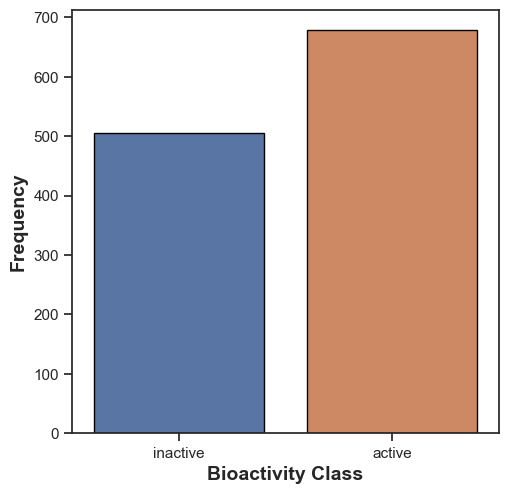

In [98]:
plt.figure(figsize=(5.5, 5.5))

sns.countplot(x='bioactivity_class', data=df_2class, edgecolor='black', hue='bioactivity_class')

plt.xlabel('Bioactivity Class', fontsize=14, fontweight='bold')
plt.ylabel('Frequency', fontsize=14, fontweight='bold')

plt.savefig('results/plot_bioactivity_class.pdf')

Scatter plot of MW versus LogP

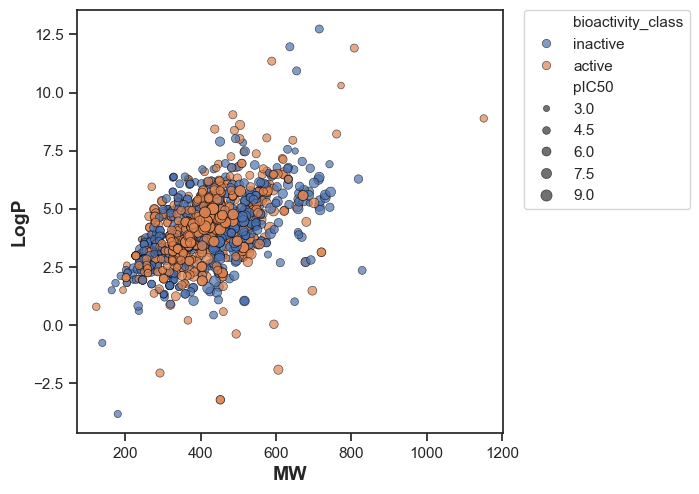

In [99]:
plt.figure(figsize=(5.5, 5.5))

sns.scatterplot(x="MW", y="LogP", data=df_2class, hue='bioactivity_class', size='pIC50', edgecolor='black', alpha=0.7)

plt.xlabel('MW', fontsize=14, fontweight='bold')
plt.ylabel('LogP', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0)

plt.savefig('results/plot_MW_vs_LogP.pdf')

#### Box Plots

pIC50 Box Plot

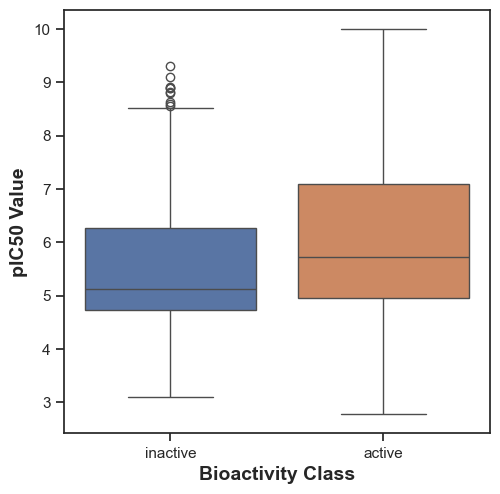

In [100]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x='bioactivity_class', y='pIC50', data=df_2class, hue='bioactivity_class')

plt.xlabel('Bioactivity Class', fontsize=14, fontweight='bold')
plt.ylabel('pIC50 Value', fontsize=14, fontweight='bold')

plt.savefig('results/plot_pIC50.pdf')

Mann-Whitney function to calculate difference in distributions

In [101]:
def mannwhitney(descriptor, verbose=False):
  # https://machinelearningmastery.com/nonparametric-statistical-significance-tests-in-python/
  from numpy.random import seed
  from numpy.random import randn
  from scipy.stats import mannwhitneyu

# seed the random number generator
  seed(1)

# actives and inactives
  selection = [descriptor, 'bioactivity_class']
  df = df_2class[selection]
  active = df[df['bioactivity_class'] == 'active']
  active = active[descriptor]

  selection = [descriptor, 'bioactivity_class']
  df = df_2class[selection]
  inactive = df[df['bioactivity_class'] == 'inactive']
  inactive = inactive[descriptor]

# compare samples
  stat, p = mannwhitneyu(active, inactive)
  #print('Statistics=%.3f, p=%.3f' % (stat, p))

# interpret
  alpha = 0.05
  if p > alpha:
    interpretation = 'Same distribution (fail to reject H0)'
  else:
    interpretation = 'Different distribution (reject H0)'
  
  results = pd.DataFrame({'Descriptor':descriptor,
                          'Statistics':stat,
                          'p':p,
                          'alpha':alpha,
                          'Interpretation':interpretation}, index=[0])
  filename = 'mannwhitneyu_' + descriptor + '.csv'
  results.to_csv(f'results/{filename}')

  return results

In [102]:
mannwhitney('pIC50')

,Descriptor,Statistics,p,alpha,Interpretation
0,pIC50,206811.0,1.222113e-09,0.05,Different distribution (reject H0)


MW Box Plot

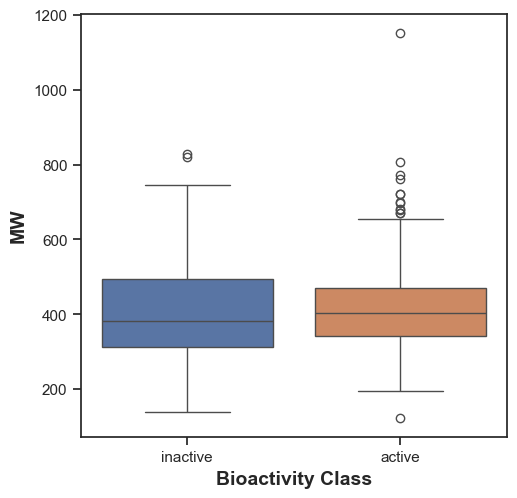

In [103]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x='bioactivity_class', y='MW', data=df_2class, hue='bioactivity_class')

plt.xlabel('Bioactivity Class', fontsize=14, fontweight='bold')
plt.ylabel('MW', fontsize=14, fontweight='bold')

plt.savefig('results/plot_MW.pdf')

In [104]:
mannwhitney('MW')

,Descriptor,Statistics,p,alpha,Interpretation
0,MW,178917.5,0.199263,0.05,Same distribution (fail to reject H0)


LogP Box Plot

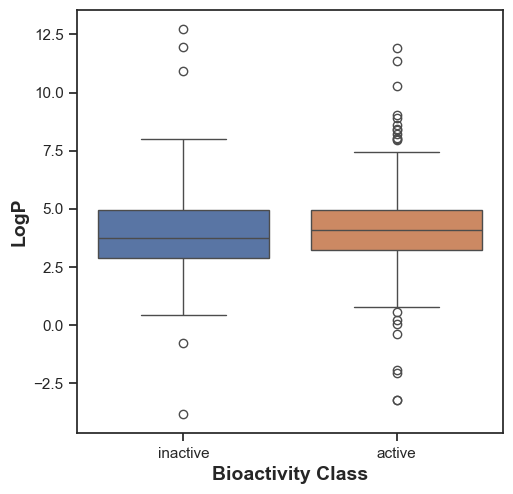

In [105]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x='bioactivity_class', y='LogP', data=df_2class, hue='bioactivity_class')

plt.xlabel('Bioactivity Class', fontsize=14, fontweight='bold')
plt.ylabel('LogP', fontsize=14, fontweight='bold')

plt.savefig('results/plot_LogP.pdf')

In [106]:
mannwhitney('LogP')

,Descriptor,Statistics,p,alpha,Interpretation
0,LogP,188308.0,0.003762,0.05,Different distribution (reject H0)


NumHDonors Box Plot

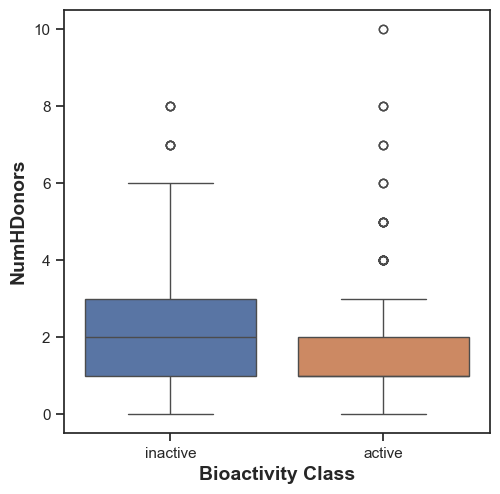

In [107]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x='bioactivity_class', y='NumHDonors', data=df_2class, hue='bioactivity_class')

plt.xlabel('Bioactivity Class', fontsize=14, fontweight='bold')
plt.ylabel('NumHDonors', fontsize=14, fontweight='bold')

plt.savefig('results/plot_NumHDonors.pdf')

In [108]:
mannwhitney('NumHDonors')

,Descriptor,Statistics,p,alpha,Interpretation
0,NumHDonors,130968.0,3.704785e-13,0.05,Different distribution (reject H0)


NumHAcceptors Box Plot

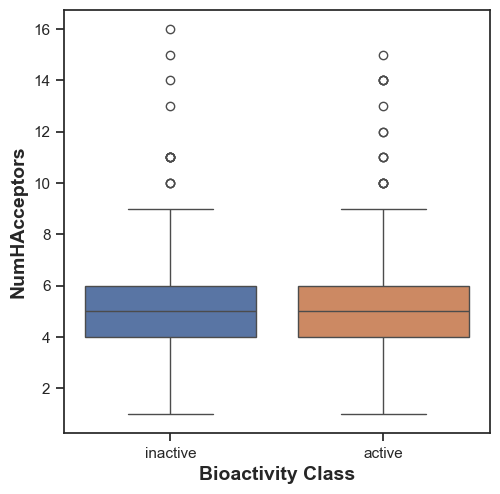

In [109]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x='bioactivity_class', y='NumHAcceptors', data=df_2class, hue='bioactivity_class')

plt.xlabel('Bioactivity Class', fontsize=14, fontweight='bold')
plt.ylabel('NumHAcceptors', fontsize=14, fontweight='bold')

plt.savefig('results/plot_NumHAcceptors.pdf')

In [110]:
mannwhitney('NumHAcceptors')

,Descriptor,Statistics,p,alpha,Interpretation
0,NumHAcceptors,158750.5,0.025924,0.05,Different distribution (reject H0)


### Interpretation of Statistical Results
**pIC50 Values:** \
Actives and inactives displayed statistically significant difference for pIC50, which is to be expected since threshold values (IC50 < 1,000 nM = Actives while IC50 > 10,000 nM = Inactives, corresponding to pIC50 > 6 = Actives and pIC50 < 5 = Inactives) were used to define actives and inactives.

**Lipinski's descriptors:** \
3/4 of Lipinski's descriptors (all except molecular weight) exhibited statistically significant difference between the actives and inactives.